In [1]:
import numpy as np
import matplotlib.pyplot as plt
from funciones import DFT

c:\Users\Lucas\Modelado Continuo\venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Lucas\Modelado Continuo\venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


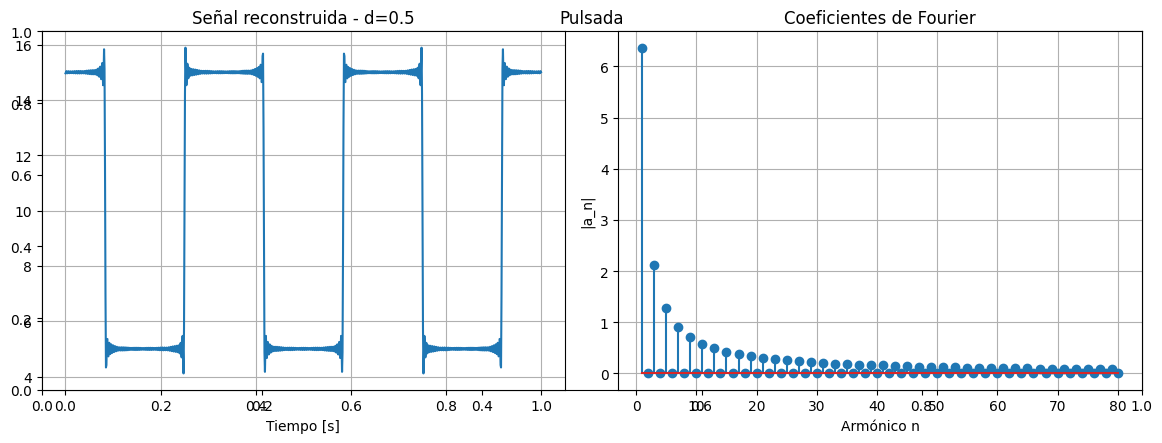

In [2]:
# Parámetros
A = 10
d = 0.5

f0 = 3
w0 = 2 * np.pi * f0

N = 80                     # cantidad de armónicos
t = np.arange(0, 1, 1/1000)

# ----------------------------
# Pulsada
# ----------------------------

pulsada = A

coeficientes = []

for n in range(1, N + 1):

    # coeficiente de Fourier
    c_n = (2 * A * np.sin(n * np.pi * d)) / (n * np.pi)

    coeficientes.append(c_n)

    # suma de armónicos
    pulsada += c_n * np.exp(1j * n * w0 * t)

# ----------------------------
# Gráficos
# ----------------------------

armonicos = np.arange(1, N + 1)

plt.figure(figsize=(12,5))
plt.title(f'Pulsada')

# Señal reconstruida
plt.subplot(1,2,1)
plt.plot(t, pulsada)
plt.title(f'Señal reconstruida - d={d}')
plt.xlabel('Tiempo [s]')
plt.grid(True)

# Coeficientes de Fourier
plt.subplot(1,2,2)
plt.stem(armonicos, np.abs(coeficientes))
plt.title('Coeficientes de Fourier')
plt.xlabel('Armónico n')
plt.ylabel('|a_n|')
plt.grid(True)

plt.tight_layout()
plt.show()

In [3]:
coeficientes

[np.float64(6.366197723675814),
 np.float64(3.898171832519376e-16),
 np.float64(-2.1220659078919377),
 np.float64(-3.898171832519376e-16),
 np.float64(1.2732395447351628),
 np.float64(3.8981718325193754e-16),
 np.float64(-0.9094568176679734),
 np.float64(-3.898171832519376e-16),
 np.float64(0.7073553026306459),
 np.float64(3.898171832519376e-16),
 np.float64(-0.5787452476068922),
 np.float64(-3.8981718325193754e-16),
 np.float64(0.4897075172058318),
 np.float64(3.898171832519376e-16),
 np.float64(-0.4244131815783876),
 np.float64(-3.898171832519376e-16),
 np.float64(0.3744822190397537),
 np.float64(3.898171832519376e-16),
 np.float64(-0.33506303808820076),
 np.float64(-3.898171832519376e-16),
 np.float64(0.3031522725559911),
 np.float64(1.4178752621088318e-15),
 np.float64(-0.2767912053772093),
 np.float64(-3.8981718325193754e-16),
 np.float64(0.25464790894703254),
 np.float64(-4.800781142423575e-16),
 np.float64(-0.235785100876882),
 np.float64(-3.898171832519376e-16),
 np.float64(0.2

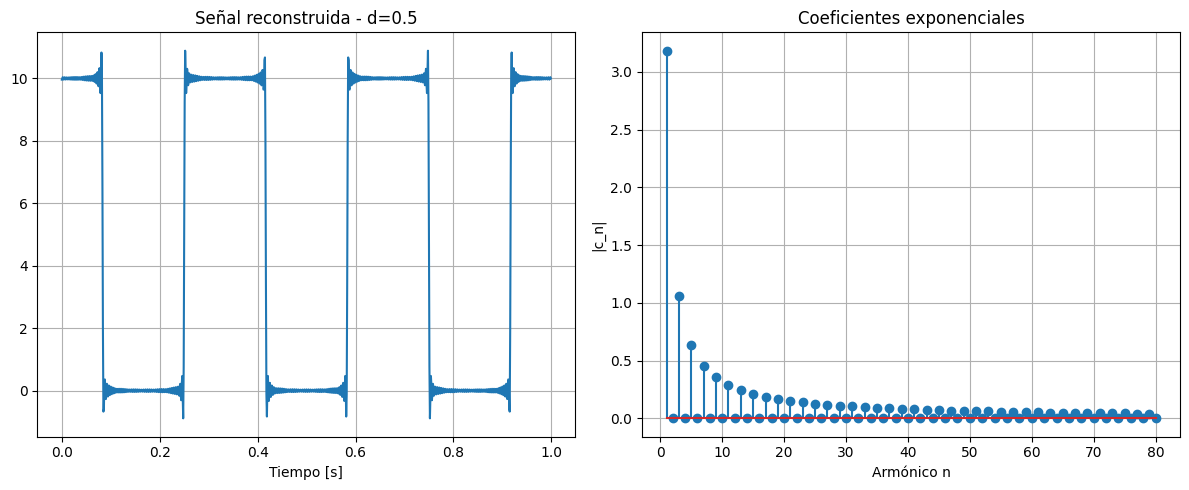

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
A = 10
d = 0.5

f0 = 3
w0 = 2 * np.pi * f0

N = 80
t = np.arange(0, 1, 1/1000)

# ----------------------------
# Reconstrucción
# ----------------------------

# término medio
pulsada = A * d * np.ones_like(t, dtype=complex)

coeficientes = []

for n in range(1, N + 1):

    # coeficiente exponencial
    c_n = A * np.sin(n * np.pi * d) / (n * np.pi)

    coeficientes.append(c_n)

    # suma de positivos y negativos
    pulsada += c_n * np.exp(1j * n * w0 * t)
    pulsada += c_n * np.exp(-1j * n * w0 * t)

# parte real
pulsada = np.real(pulsada)

# ----------------------------
# Gráficos
# ----------------------------

armonicos = np.arange(1, N + 1)

plt.figure(figsize=(12,5))

# señal
plt.subplot(1,2,1)
plt.plot(t, pulsada)
plt.title(f'Señal reconstruida - d={d}')
plt.xlabel('Tiempo [s]')
plt.grid(True)

# coeficientes
plt.subplot(1,2,2)
plt.stem(armonicos, np.abs(coeficientes))
plt.title('Coeficientes exponenciales')
plt.xlabel('Armónico n')
plt.ylabel('|c_n|')
plt.grid(True)

plt.tight_layout()
plt.show()